# Python script for recreating Augenstreich et al. data analysis

Nativelty in Python rather than using Python bindings for ImageJ. Also uses newest CellPose SAM

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from cellpose import models, io

from skimage import io as skio
from skimage.color import label2rgb
from skimage.transform import rescale, resize
from skimage import measure, filters, color, exposure

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

io.logger_setup()

2026-03-25 13:29:40,227 [INFO] WRITING LOG OUTPUT TO C:\Users\ellag\.cellpose\run.log
2026-03-25 13:29:40,230 [INFO] 
cellpose version: 	4.0.9 
platform:       	win32 
python version: 	3.13.12 
torch version:  	2.10.0+cpu


(<Logger cellpose.io (INFO)>, WindowsPath('C:/Users/ellag/.cellpose/run.log'))

## Loading file

In [2]:
directory_path = Path("C:/Users/ellag/Meijer Lab/Imaging data/THP-1 cells/tif_files/ULK101/Round 1/1uM")
filename = "ULK101_1 uM_4.tif"

out = directory_path / "Output"
out.mkdir(exist_ok=True)

In [3]:
image_data = skio.imread(directory_path / filename)

# Shape should be (Z, C, Y, X).
print(f"Original image shape: {image_data.shape}")

Original image shape: (22, 1024, 1024, 4)


## Z-stack maximum intensity projection

In [4]:
mip_image = np.max(image_data, axis=0)  # MIP

print(f"Flattened image shape: {mip_image.shape} (Expected: X, Y, C)")

# Extract the channels (C is the last dimension, so we slice the 3rd axis)
channel_dapi = mip_image[:, :, 0]
channel_lc3 = mip_image[:, :, 1]
channel_brightfield = mip_image[:, :, 2]
channel_mav = mip_image[:, :, 3]

Flattened image shape: (1024, 1024, 4) (Expected: X, Y, C)


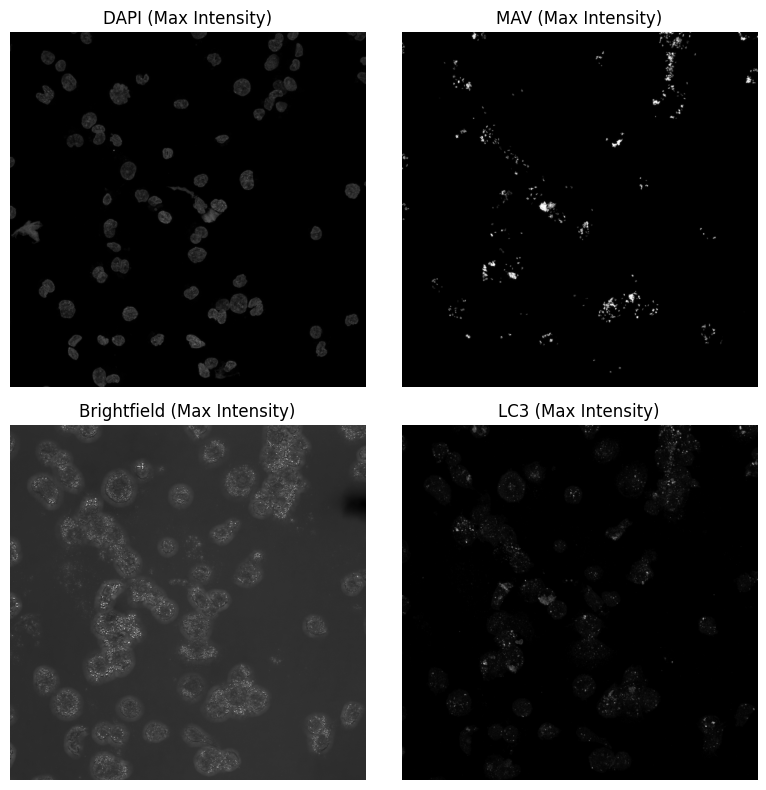

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
ax = axs.ravel()

# DAPI
ax[0].imshow(channel_dapi, cmap="gray")
ax[0].set_title("DAPI (Max Intensity)")
ax[0].axis("off")

# MAV
ax[1].imshow(channel_mav, cmap="gray")
ax[1].set_title("MAV (Max Intensity)")
ax[1].axis("off")

# Brightfield
ax[2].imshow(channel_brightfield, cmap="gray")
ax[2].set_title("Brightfield (Max Intensity)")
ax[2].axis("off")

# LC3
ax[3].imshow(channel_lc3, cmap="gray")
ax[3].set_title("LC3 (Max Intensity)")
ax[3].axis("off")

plt.tight_layout()

## MAV cluster detection

In [6]:
min_blob_size = 10 # Minimum area in pixels
max_blob_size = 1000 # Maximum area in pixels

# 1. Create the binary image (The part that was missing)
# Make sure 'channel_mav' is defined from your image loading step
thresh_mav = filters.threshold_otsu(channel_mav)
binary_mav = channel_mav > thresh_mav

# 2. Label the binary image
labeled_mav = measure.label(binary_mav)

# Lists to store our data
centroids_x, centroids_y = [], []
blob_contours = []

# 3. Filter by size and trace boundaries
for prop in measure.regionprops(labeled_mav):
    if min_blob_size <= prop.area <= max_blob_size:
        # Store Centroid
        y, x = prop.centroid
        centroids_y.append(y)
        centroids_x.append(x)
        
        # Trace the boundary (the "outside") of this specific blob
        # This creates a contour at the 0.5 intensity level of the binary mask
        object_mask = (labeled_mav == prop.label)
        contours = measure.find_contours(object_mask, 0.5)
        
        if contours:
            blob_contours.append(contours[0])

print(f"Successfully identified and traced {len(blob_contours)} blobs.")

Successfully identified and traced 182 blobs.


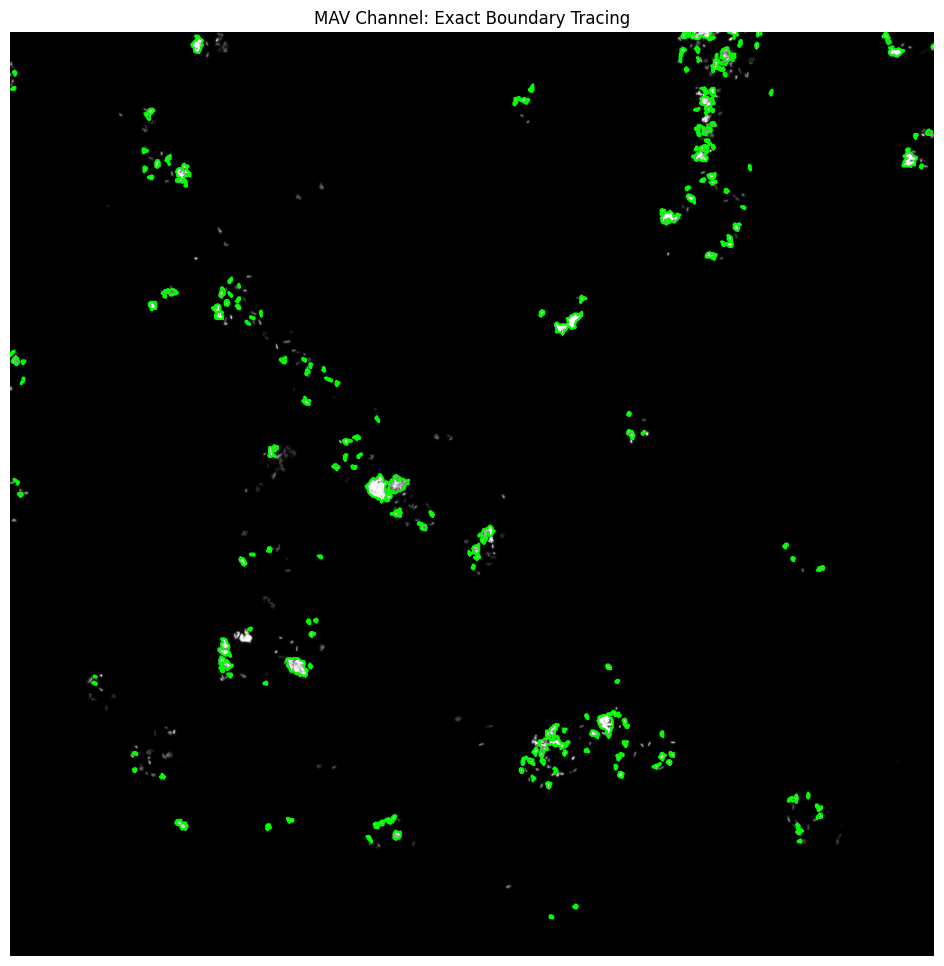

In [7]:
fig, ax = plt.subplots(figsize=(12, 12))

# Display the original MAV channel
ax.imshow(channel_mav, cmap="gray")

# Plot each contour (the "trace")
for contour in blob_contours:
    # Note: find_contours returns (row, col) which is (y, x)
    ax.plot(contour[:, 1], contour[:, 0], color="lime", linewidth=1.5)

ax.set_title("MAV Channel: Exact Boundary Tracing")
ax.axis("off")
plt.show()

In [8]:
# 1. Filter and create a CLEAN label image
# ---------------------------------------
# Start with a blank canvas the same size as your image
clean_labeled_mav = np.zeros_like(labeled_mav)
valid_label_counter = 1

# List to store data for the 182 valid blobs
valid_blobs_data = [] 

for prop in measure.regionprops(labeled_mav):
    if min_blob_size <= prop.area <= max_blob_size:
        # Paint ONLY this valid blob onto our clean canvas
        # We give it a new, sequential ID (1, 2, 3...)
        clean_labeled_mav[labeled_mav == prop.label] = valid_label_counter
        valid_label_counter += 1

# Verify the count
num_valid = valid_label_counter - 1
print(f"Cleaned image contains {num_valid} blobs.")

Cleaned image contains 182 blobs.


## Create radii

In [9]:
# Settings
n_steps = 10  # Total steps (1 internal + 9 outward)
num_blobs = int(clean_labeled_mav.max())
profile_matrix = np.zeros((num_blobs, n_steps))

print(f"Generating 10-step area-normalized profiles for {num_blobs} blobs...")

for i in range(1, num_blobs + 1):
    # 1. Isolate the "Trace" (The starting blob)
    current_mask = (clean_labeled_mav == i)
    
    # --- NEW: Calculate the area of the original bacterial blob ---
    blob_area = np.sum(current_mask)
    
    # Safety check: If a blob somehow has 0 area, skip it to avoid division by zero
    if blob_area == 0:
        profile_matrix[i-1, :] = np.nan
        continue
    
    # --- Step 0: The interior of the trace ---
    internal_values = channel_lc3[current_mask]
    if len(internal_values) > 0:
        # Divide the mean intensity by the original blob area
        profile_matrix[i-1, 0] = np.mean(internal_values) / blob_area
    else:
        profile_matrix[i-1, 0] = np.nan

    # --- Steps 1 to 9: Expanding Outwards ---
    previous_mask = current_mask
    for step in range(1, n_steps):
        # Grow the shape by 1 pixel
        expanded_mask = binary_dilation(previous_mask)
        
        # Identify the new "ring" (XOR operation: pixels in expanded but not in previous)
        ring_mask = expanded_mask ^ previous_mask 
        
        # Sample LC3 intensity from this specific ring
        ring_values = channel_lc3[ring_mask]
        
        if len(ring_values) > 0:
            # Divide the mean intensity of the ring by the original blob area
            profile_matrix[i-1, step] = np.mean(ring_values) / blob_area
        else:
            # Handle cases where expansion hits the image edge or is empty
            profile_matrix[i-1, step] = np.nan
            
        # Update for the next expansion step
        previous_mask = expanded_mask

print("Profile Matrix Generation Complete.")
print(f"Shape: {profile_matrix.shape} (Row: Blob, Column: Distance from Trace)")

Generating 10-step area-normalized profiles for 182 blobs...
Profile Matrix Generation Complete.
Shape: (182, 10) (Row: Blob, Column: Distance from Trace)


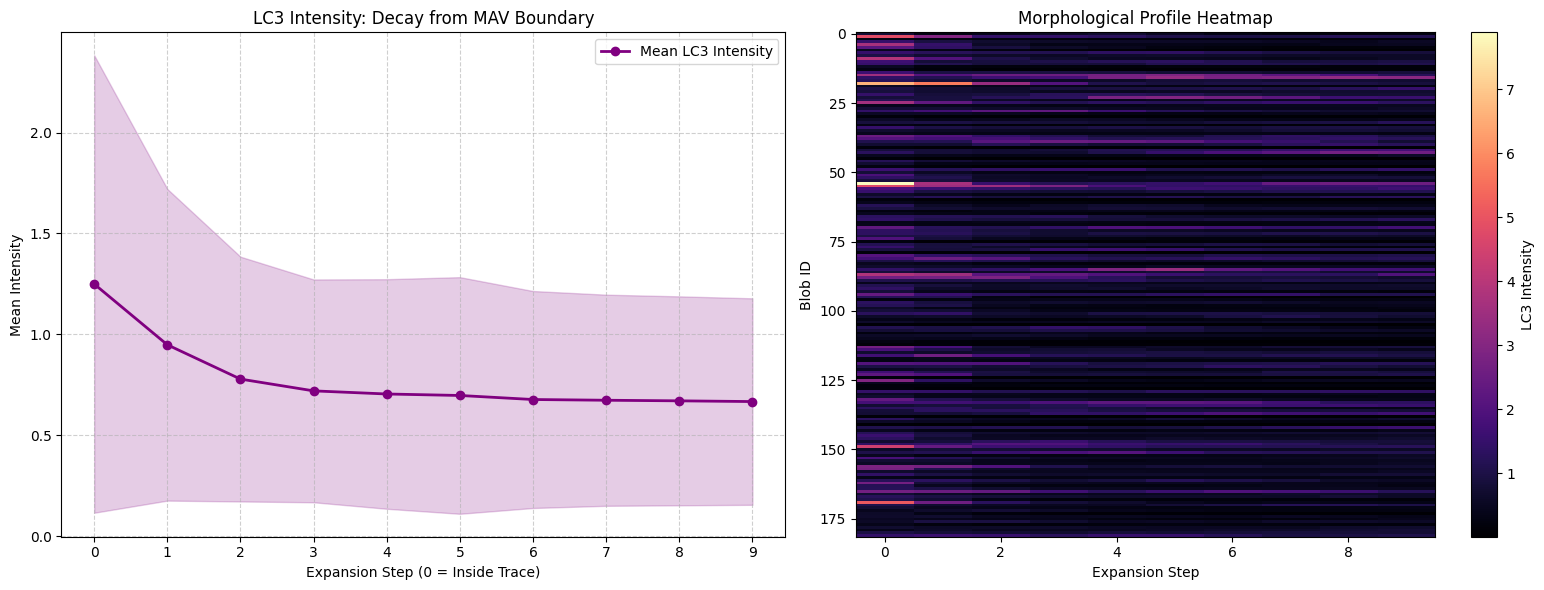

In [10]:
# 1. Prepare the X-axis (Steps 0 to 9 for your 10-step throughput)
steps = np.arange(profile_matrix.shape[1])

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Mean Morphological Profile ---
# Calculate mean and standard deviation across all blobs (ignoring NaNs)
mean_profile = np.nanmean(profile_matrix, axis=0)
std_profile = np.nanstd(profile_matrix, axis=0)

axs[0].plot(steps, mean_profile, color="purple", lw=2, marker='o', label="Mean LC3 Intensity")
axs[0].fill_between(
    steps,
    mean_profile - std_profile,
    mean_profile + std_profile,
    color="purple",
    alpha=0.2,
)

axs[0].set_title("LC3 Intensity: Decay from MAV Boundary")
axs[0].set_xlabel("Expansion Step (0 = Inside Trace)")
axs[0].set_ylabel("Mean Intensity")
axs[0].set_xticks(steps) # Ensure every step is marked
axs[0].grid(True, linestyle="--", alpha=0.6)
axs[0].legend()

# --- Plot 2: Heatmap of the Profile Matrix ---
# Each row is a blob, each column is a distance step
im = axs[1].imshow(profile_matrix, aspect="auto", cmap="magma", interpolation="none")
axs[1].set_title("Morphological Profile Heatmap")
axs[1].set_xlabel("Expansion Step")
axs[1].set_ylabel("Blob ID")
fig.colorbar(im, ax=axs[1], label="LC3 Intensity")

plt.tight_layout()
plt.show()

In [20]:
n_clusters = 3

# Filter out blobs that hit the edge of the image (which contain NaNs)
valid_rows = ~np.isnan(profile_matrix).any(axis=1)
clean_matrix = profile_matrix[valid_rows]

valid_blob_indices = np.where(valid_rows)[0]
print(
    f"Using {len(clean_matrix)} out of {len(profile_matrix)} blobs (filtered out edge cases)."
)

# Define our new X-axis (Steps 0 to 9)
steps = np.arange(clean_matrix.shape[1])

# Extract features: Fit a 2nd degree polynomial to the decay curve of each blob
# We use 'steps' instead of 'radii' here
coeffs = np.polyfit(steps, clean_matrix.T, deg=2)

# The features are the polynomial coefficients (curvature, slope, intercept)
features = coeffs.T

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Run K-Means Clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)

print(f"Clustering complete. Grouped into {n_clusters} clusters.")

Using 182 out of 182 blobs (filtered out edge cases).
Clustering complete. Grouped into 3 clusters.


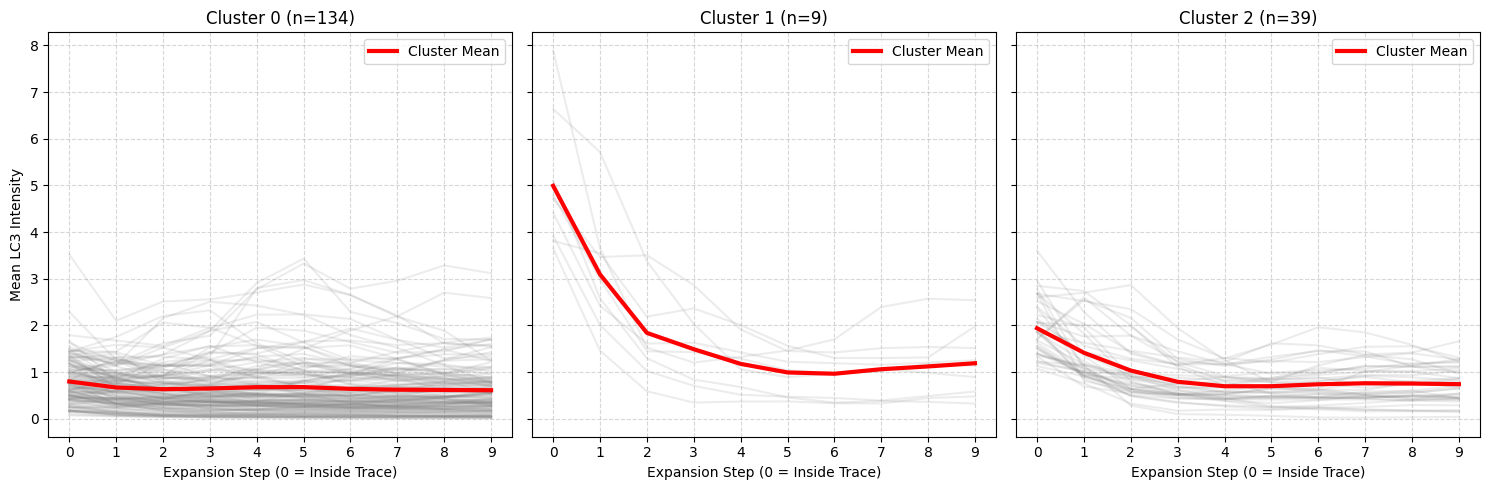

In [21]:
# Define our steps array for the X-axis (0 to 9)
steps = np.arange(clean_matrix.shape[1])

# Create side-by-side plots for each cluster
fig, axs = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5), sharey=True)

for i in range(n_clusters):
    # Isolate the profiles belonging to the current cluster
    cluster_profiles = clean_matrix[cluster_labels == i]

    # Plot all individual profiles in this cluster faintly
    for prof in cluster_profiles:
        axs[i].plot(steps, prof, color="gray", alpha=0.15)

    # Calculate and plot the mean profile for this cluster
    if len(cluster_profiles) > 0:
        mean_prof = np.mean(cluster_profiles, axis=0)
        axs[i].plot(steps, mean_prof, color="red", linewidth=3, label="Cluster Mean")

    # Update titles and labels for the new logic
    axs[i].set_title(f"Cluster {i} (n={len(cluster_profiles)})")
    axs[i].set_xlabel("Expansion Step (0 = Inside Trace)")
    axs[i].set_xticks(steps)  # Forces the x-axis to show every step clearly
    axs[i].grid(True, linestyle="--", alpha=0.5)
    
    if i == 0:
        axs[i].set_ylabel("Mean LC3 Intensity")
        
    axs[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Recreate the coordinate arrays from your original centroid lists
x_coords = np.array(centroids_x)
y_coords = np.array(centroids_y)

crop_size = 25  # 25 px in all directions = 50x50px crop
output_base = directory_path / "Output"

def rgb_from_lc3_and_mav(lc3: np.ndarray, mav: np.ndarray, brightfield: np.ndarray):
    """Create RGB from LC3, MAV, and brightfield image
    Brightfield is shown as grayscale. MAV is shown in magenta. LC3 is shown in green.
    """
    bf_norm = exposure.rescale_intensity(brightfield, out_range=(0.0, 1.0))
    lc3_norm = exposure.rescale_intensity(lc3, out_range=(0.0, 1.0))
    mav_norm = exposure.rescale_intensity(mav, out_range=(0.0, 1.0))

    r = np.clip((bf_norm * 0.5) + mav_norm, 0, 1)
    g = np.clip((bf_norm * 0.5) + lc3_norm, 0, 1)
    b = np.clip((bf_norm * 0.5) + mav_norm, 0, 1)

    return np.dstack((r, g, b))

global_rgb = rgb_from_lc3_and_mav(channel_lc3, channel_mav, channel_brightfield)
img_h, img_w = global_rgb.shape[:2]

print(f"Generating ROI plots for {len(cluster_labels)} blobs...")

# --- Define the X-axis for the plots (Steps 0 to 9) ---
steps = np.arange(clean_matrix.shape[1])

for i, cluster_id in enumerate(cluster_labels):
    blob_idx = valid_blob_indices[i]
    cx = int(x_coords[blob_idx])
    cy = int(y_coords[blob_idx])
    profile = clean_matrix[i]

    cluster_dir = output_base / f"Cluster_{cluster_id}"
    cluster_dir.mkdir(parents=True, exist_ok=True)

    y_min, y_max = cy - crop_size, cy + crop_size
    x_min, x_max = cx - crop_size, cx + crop_size

    pad_top = max(0, -y_min)
    pad_bottom = max(0, y_max - img_h)
    pad_left = max(0, -x_min)
    pad_right = max(0, x_max - img_w)

    y_min_safe, y_max_safe = max(0, y_min), min(img_h, y_max)
    x_min_safe, x_max_safe = max(0, x_min), min(img_w, x_max)

    roi_rgb = global_rgb[y_min_safe:y_max_safe, x_min_safe:x_max_safe]

    if pad_top > 0 or pad_bottom > 0 or pad_left > 0 or pad_right > 0:
        roi_rgb = np.pad(
            roi_rgb,
            ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
            mode="constant",
        )

    fig, axs = plt.subplots(
        1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [3, 1]}
    )

    # Left Plot: 50x50 RGB Composite
    axs[0].imshow(roi_rgb)
    axs[0].set_title(f"Blob {blob_idx} | MAV: Magenta, LC3: Green")
    axs[0].axis("off")

    # Add a subtle crosshair to the exact center of the crop
    axs[0].plot(
        crop_size, crop_size, marker="+", color="white", markersize=10, alpha=0.7
    )

    # Right Plot: Morphological Profile
    axs[1].plot(steps, profile, color="red", linewidth=2, marker="o", markersize=4)
    axs[1].set_title("LC3 Profile")
    axs[1].set_xlabel("Expansion Step")
    axs[1].set_xticks(steps)
    axs[1].grid(True, linestyle="--", alpha=0.5)

    plt.suptitle(f"Cluster {cluster_id}", fontsize=14, fontweight="bold")
    plt.tight_layout()

    # Actually save the figure to the folder!
    save_path = cluster_dir / f"Cluster_{cluster_id}_blob_{blob_idx}_roi.jpg"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.close(fig)  # Close the figure so it doesn't crash your RAM

print(f"Successfully saved all ROIs to {output_base.absolute()}")

Generating ROI plots for 182 blobs...
